In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import periodogram

# Mutually coupled van der Pol oscillators

Eqs. (2.8)-(2.11) of the Lecture notes (p. 20)

In [2]:
def vdp_coupled(t, state, lambda1, lambda2, w1, w2, Bd):
    x1, y1, x2, y2 = state
    return (y1,
            (lambda1 - x1**2)*y1 - w1**2*x1 + Bd*(y2 - y1),
            y2,
            (lambda2 - x2**2)*y2 - w2**2*x2 + Bd*(y1 - y2)
           )

# Frequency locking (Lecture notes section 1.2.1) -- Steady state

In [3]:
state_initial = (-0.5, 0.1, 0.5, 0.1)

t_span = [0, 2000]

lambda1=0.1
lambda2=0.1

w1=1.0
w2=0.98
Bd=0.0 # No coupling

In order to calculate power spectrum using standard tools (scipy.signal.periodogram or .welch functions assume constant time step), we obtain solution of the system at **equidistant** time points by specifying time points at which we want to obtain the solution. This we do by passing an array of time points to `t_eval` parameter in `solve_ivp` function.

In [4]:
dt = 0.01 # sec

t_start = 1000 # We are only interested in the system's dyncamis in the steady state,
               # so we skip the initial part of the solution, where the system evolves
               # to its steady state. In order to see how the system evolves and
               # becomes synchronized, change t_start to 0.

t_eval = np.arange(t_start, t_span[1], dt)

In [5]:
solution = solve_ivp(vdp_coupled,
                     t_span, state_initial,
                     args=(lambda1, lambda2, w1, w2, Bd), t_eval=t_eval)

[freqs, pxx1] = periodogram(solution.y[0], fs=1/dt, nfft=t_eval.size)
[_, pxx2] = periodogram(solution.y[2], fs=1/dt, nfft=t_eval.size)

## Show $x_1(t)$ and $x_2(t)$

Text(0.5, 0, 'Time (sec)')

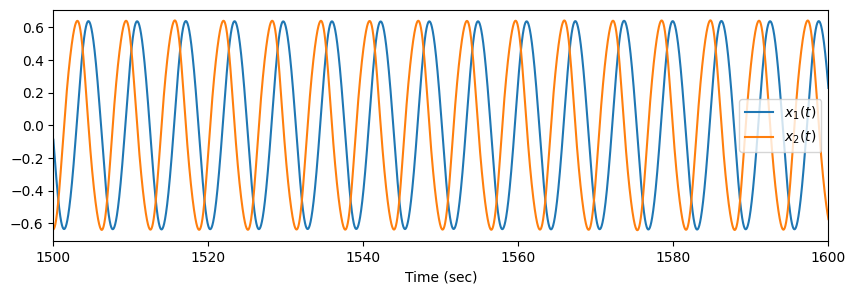

In [6]:
f, ax = plt.subplots(figsize=(10, 3))

ax.plot(solution.t, solution.y[0], label='$x_1(t)$')
ax.plot(solution.t, solution.y[1], label='$x_2(t)$')

ax.set_xlim(1500, 1600)
ax.legend()

ax.set_xlabel('Time (sec)')

## Lessajous curves and power spectra at $B_D = 0$ (Fig. 1.1)

Text(0.5, 1.0, 'Power spectral density. B$_D$=0.0')

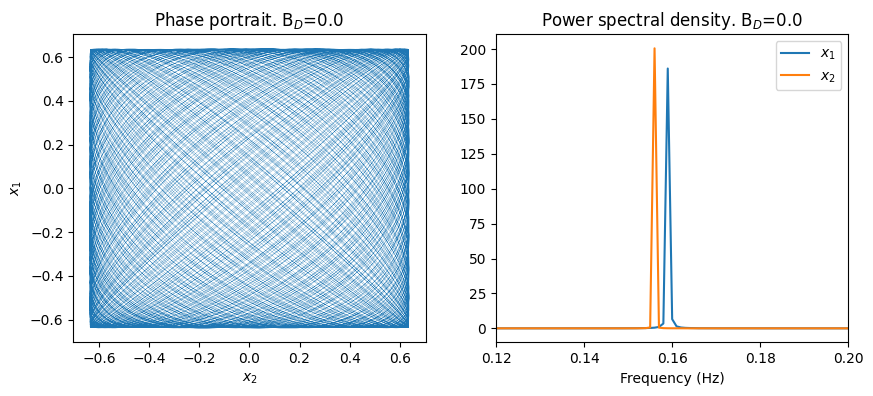

In [7]:
f, (ax_les, ax_pxx) = plt.subplots(1,2, figsize=(10, 4))

ax_les.plot(solution.y[0], solution.y[2], lw=0.2)
ax_les.set_ylabel('$x_1$')
ax_les.set_xlabel('$x_2$')
ax_les.set_title(f'Phase portrait. B$_D$={Bd}')


ax_pxx.plot(freqs, pxx1, label='$x_1$')
ax_pxx.plot(freqs, pxx2, label='$x_2$')
ax_pxx.legend()
ax_pxx.set_xlim(0.12, 0.2)
ax_pxx.set_xlabel('Frequency (Hz)')
ax_pxx.set_title(f'Power spectral density. B$_D$={Bd}')

## Lessajous curves and power spectra at $B_D = 0.015$ (Fig. 1.2)

In [8]:
Bd=0.015

solution = solve_ivp(vdp_coupled,
                     t_span, state_initial,
                     args=(lambda1, lambda2, w1, w2, Bd), t_eval=t_eval)

[freqs, pxx1] = periodogram(solution.y[0], fs=1/dt, nfft=t_eval.size)
[_, pxx2] = periodogram(solution.y[2], fs=1/dt, nfft=t_eval.size)

Text(0.5, 1.0, 'Power spectral density. B$_D$=0.015')

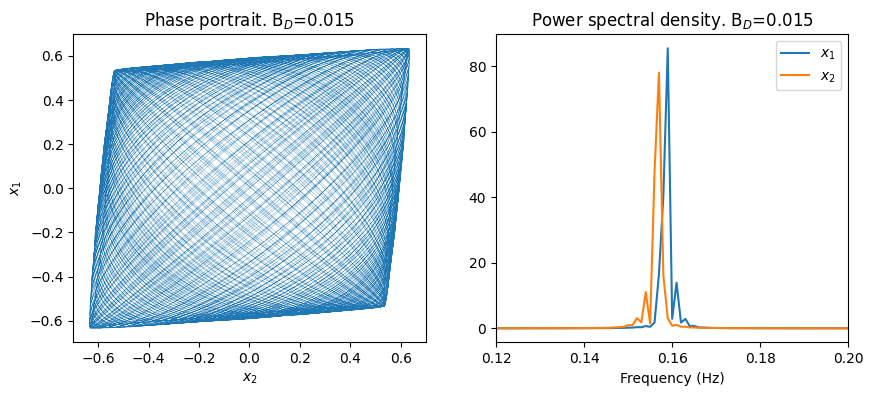

In [9]:
f, (ax_les, ax_pxx) = plt.subplots(1,2, figsize=(10, 4))

ax_les.plot(solution.y[0], solution.y[2], lw=0.2)
ax_les.set_ylabel('$x_1$')
ax_les.set_xlabel('$x_2$')
ax_les.set_title(f'Phase portrait. B$_D$={Bd}')

ax_pxx.plot(freqs, pxx1, label='$x_1$')
ax_pxx.plot(freqs, pxx2, label='$x_2$')
ax_pxx.legend()
ax_pxx.set_xlim(0.12, 0.2)
ax_pxx.set_xlabel('Frequency (Hz)')
ax_pxx.set_title(f'Power spectral density. B$_D$={Bd}')

## Lessajous curves and power spectra at $B_D = 0.028$ (Fig. 1.2)

In [10]:
Bd=0.028

solution = solve_ivp(vdp_coupled,
                     t_span, state_initial,
                     args=(lambda1, lambda2, w1, w2, Bd), t_eval=t_eval)

[freqs, pxx1] = periodogram(solution.y[0], fs=1/dt, nfft=t_eval.size)
[_, pxx2] = periodogram(solution.y[2], fs=1/dt, nfft=t_eval.size)

Text(0.5, 1.0, 'Power spectral density. B$_D$=0.028')

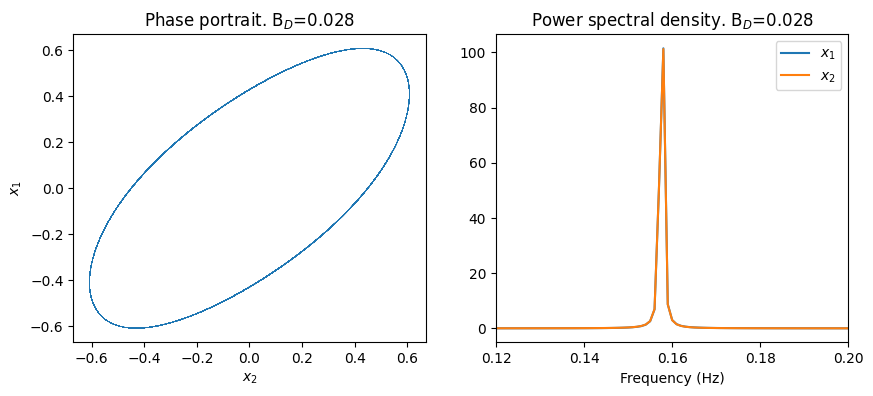

In [11]:
f, (ax_les, ax_pxx) = plt.subplots(1,2, figsize=(10, 4))

ax_les.plot(solution.y[0], solution.y[2], lw=0.2)
ax_les.set_ylabel('$x_1$')
ax_les.set_xlabel('$x_2$')
ax_les.set_title(f'Phase portrait. B$_D$={Bd}')

ax_pxx.plot(freqs, pxx1, label='$x_1$')
ax_pxx.plot(freqs, pxx2, label='$x_2$')
ax_pxx.legend()
ax_pxx.set_xlim(0.12, 0.2)
ax_pxx.set_xlabel('Frequency (Hz)')
ax_pxx.set_title(f'Power spectral density. B$_D$={Bd}')

# Suppression (Lecture notes section 1.2.2)

In [12]:
print(w2)

0.98


In [13]:
w2=0.85
print(w2)

Bd= [0, 0.09, 0.11, 0.2]

0.85


## Show Phase portraits and power spectra at each $B_D$ value (Figures 1.4-1.8)

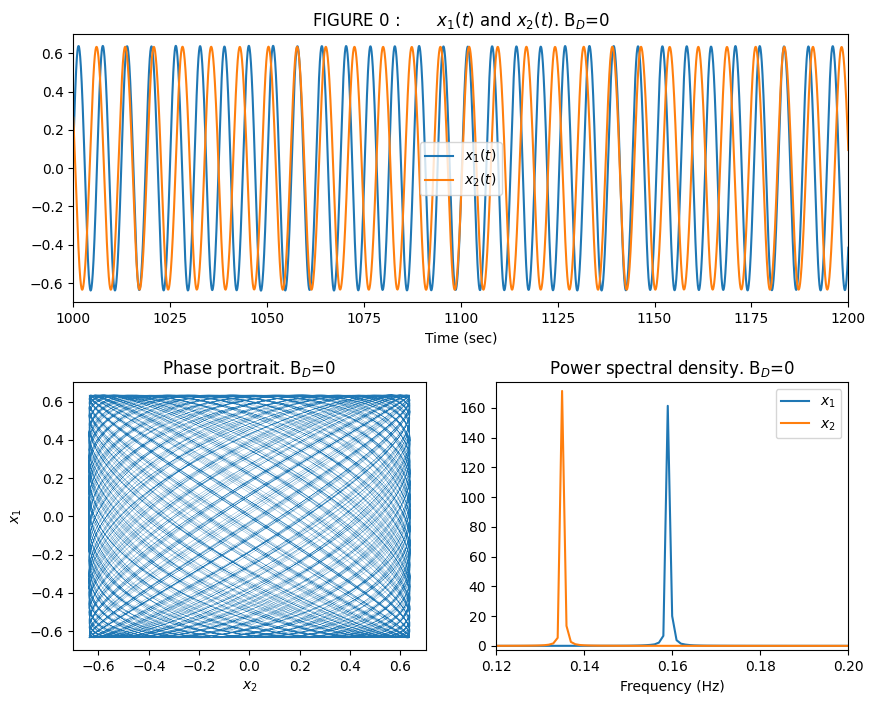

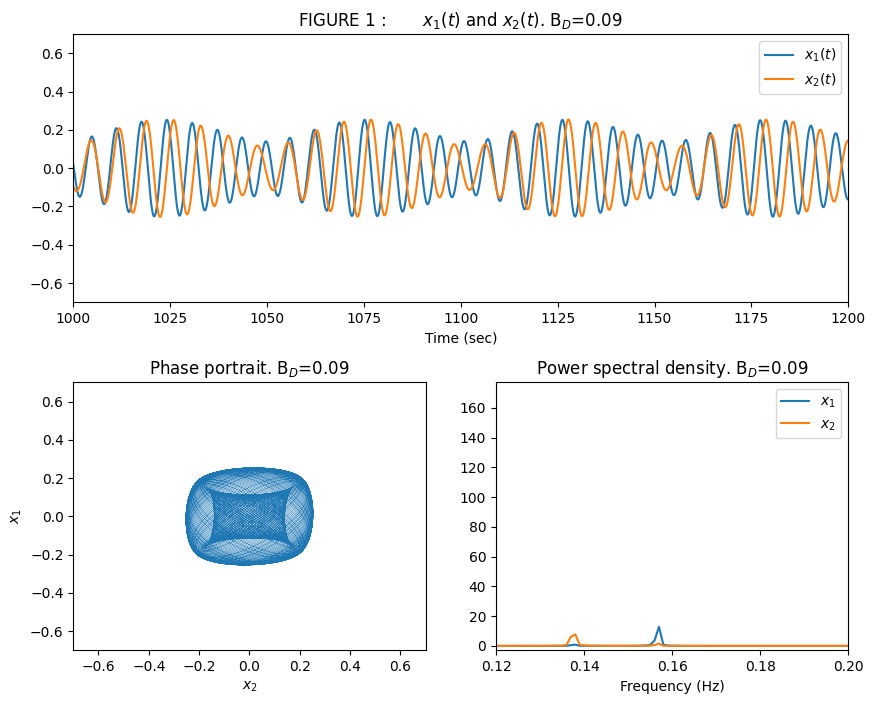

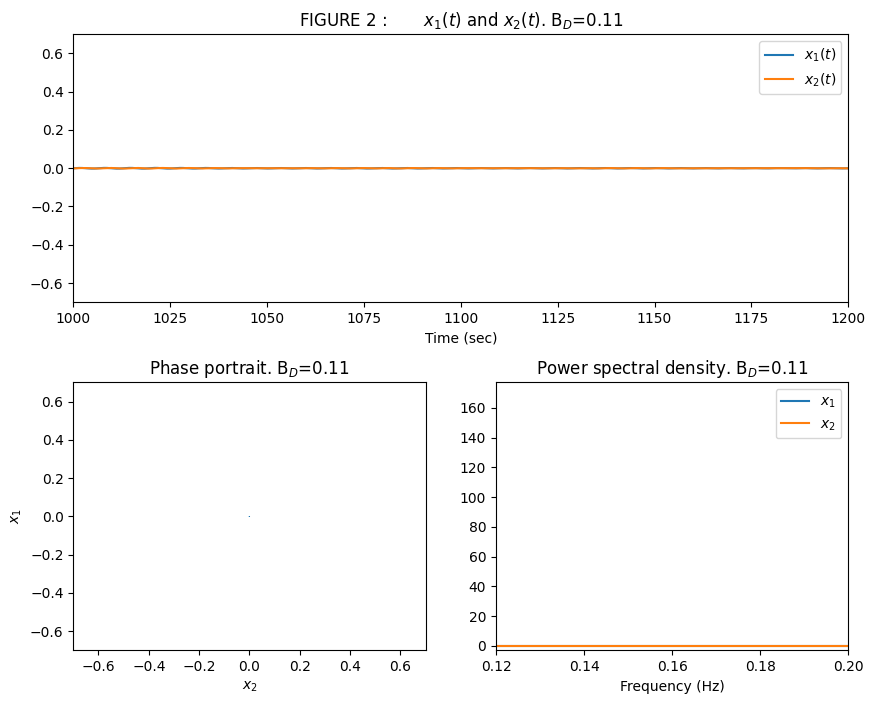

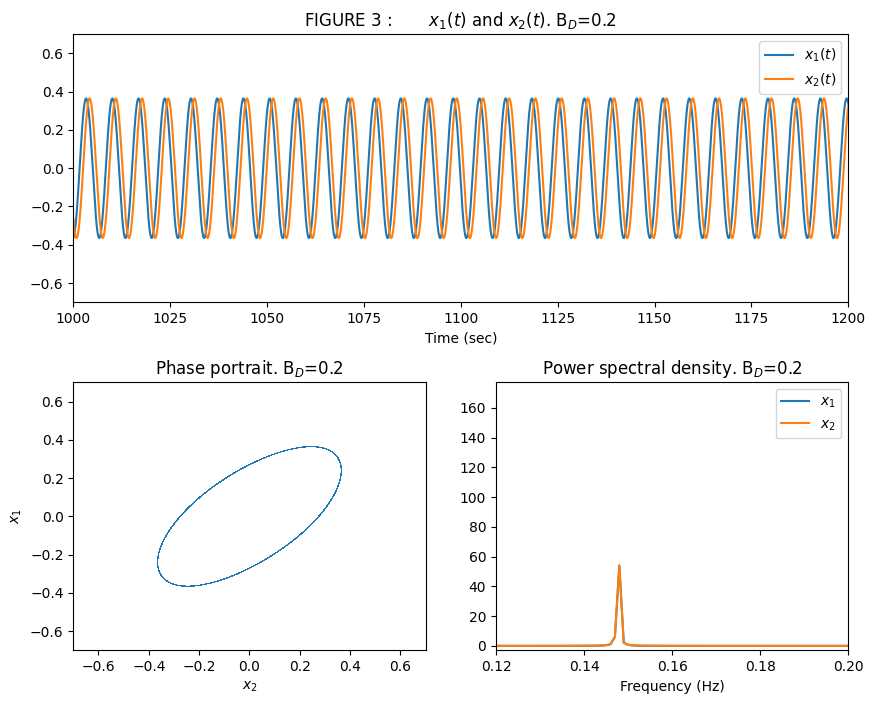

In [14]:
for i, Bd_i in enumerate(Bd):

    # solve the system

    solution = solve_ivp(vdp_coupled,
                         t_span, state_initial,
                         args=(lambda1, lambda2, w1, w2, Bd_i), t_eval=t_eval)

    # Estimate power spectral density

    [freqs, pxx1] = periodogram(solution.y[0], fs=1/dt, nfft=t_eval.size)
    [_, pxx2] = periodogram(solution.y[2], fs=1/dt, nfft=t_eval.size)

    # Make figure

    f = plt.figure(figsize=(10, 8))

    gc = plt.GridSpec(2, 2, figure=f, hspace=0.3)

    ax_traj = f.add_subplot(gc[0, :])
    ax_les =  f.add_subplot(gc[1, 0])
    ax_pxx =  f.add_subplot(gc[1, 1])


    ax_traj.plot(solution.t, solution.y[0], label='$x_1(t)$')
    ax_traj.plot(solution.t, solution.y[2], label='$x_2(t)$')
    ax_traj.set_xlim(1000, 1200)
    ax_traj.set_ylim(-0.7, 0.7)
    ax_traj.legend()
    ax_traj.set_xlabel('Time (sec)')
    ax_traj.set_title(f'FIGURE {i} :       $x_1(t)$ and $x_2(t)$. B$_D$={Bd_i}')

    ax_les.plot(solution.y[0], solution.y[2], lw=0.2)
    ax_les.set_ylabel('$x_1$')
    ax_les.set_xlabel('$x_2$')
    ax_les.set_title(f'Phase portrait. B$_D$={Bd_i}')
    ax_les.set_xlim(-0.7, 0.7)
    ax_les.set_ylim(-0.7, 0.7)

    ax_pxx.plot(freqs, pxx1, label='$x_1$')
    ax_pxx.plot(freqs, pxx2, label='$x_2$')
    ax_pxx.legend()
    ax_pxx.set_xlim(0.12, 0.2)
    ax_pxx.set_ylim(-3, 177)
    ax_pxx.set_xlabel('Frequency (Hz)')
    ax_pxx.set_title(f'Power spectral density. B$_D$={Bd_i}')
